# Initialization

In [ ]:
import torch
import torch.nn.functional as F
from diffusers import AutoPipelineForText2Image, DDPMScheduler
from peft import LoraConfig

# Load the model
torch.cuda.empty_cache()
pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

print("Initialized model!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [2]:
# Freeze base model (unet and vae) and the text encoder
pipe.unet.requires_grad_(False)
pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)

# Add LoRA adapter
lora_config = LoraConfig(
    r=4, # the rank of the matrix A and B
    lora_alpha=4, # matches the rank
    init_lora_weights="gaussian", # the initialization method for the weights
    target_modules=["to_k", "to_q", "to_v", "to_out.0"], # the modules to apply the LoRA to: keys, queries, values, and output
)
pipe.unet.add_adapter(lora_config)

In [3]:
# Prepare noise scheduler for training
noise_scheduler = DDPMScheduler.from_pretrained(
    "stabilityai/sdxl-turbo", 
    subfolder="scheduler"
)

# Prepare optimizer
optimizer = torch.optim.AdamW(
    pipe.unet.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=0.01,
)

# For a given example,

## Generate the positive image

In [4]:
# Encode prompt
with torch.no_grad():
    prompt = "A photo of an astronaut riding a horse on mars"
    prompt_embeds, _, pooled_prompt_embeds, _ = pipe.encode_prompt(
        prompt,
        device="cuda",
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
    )

    print(f"prompt_embeds: {prompt_embeds.shape, prompt_embeds.dtype}")
    print(f"pooled_prompt_embeds: {pooled_prompt_embeds.shape, pooled_prompt_embeds.dtype}")

# Generate image and encode to latents
# We'll use this as the "target" image
generator = torch.Generator(device="cuda").manual_seed(0)
target_image = pipe(
    prompt_embeds=prompt_embeds,
    pooled_prompt_embeds=pooled_prompt_embeds,
    num_images_per_prompt=1,
    generator=generator,
    width=512,
    height=512,
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]

prompt_embeds: (torch.Size([1, 77, 2048]), torch.float16)
pooled_prompt_embeds: (torch.Size([1, 1280]), torch.float16)


  0%|          | 0/1 [00:00<?, ?it/s]

In [32]:
pipe.vae.to(dtype=torch.float32) # convert vae to 32 temporarily

with torch.no_grad():
    target_image_tensor = pipe.image_processor.pil_to_numpy(target_image)
    target_image_tensor = pipe.image_processor.numpy_to_pt(target_image_tensor).to("cuda", dtype=torch.float32)
    print(f"target_image_tensor: {target_image_tensor.shape, target_image_tensor.dtype}")

    target_latents = pipe.vae.encode(target_image_tensor).latent_dist.sample()
    target_latents = target_latents.to(torch.float16)
    print(f"target_latents: {target_latents.shape, target_latents.dtype}")

pipe.vae.to(dtype=torch.float16) # convert vae back to 16

target_image_tensor: (torch.Size([1, 3, 512, 512]), torch.float32)
target_latents: (torch.Size([1, 4, 64, 64]), torch.float16)


AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [ ]:
# Training loop
num_steps = 1000
pipe.unet.train()

loss_history = deque(maxlen=window_size)

for step in range(num_steps):
    optimizer.zero_grad()
    
    # Get text embeddings (fresh each step to avoid graph issues)
    prompt_embeds, _, pooled_prompt_embeds, _ = pipe.encode_prompt(
        prompt="A photo of an astronaut riding a horse on mars",
        device="cuda",
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
    )
    
    # Sample noise and timestep
    noise = torch.randn_like(target_latents)
    bsz = target_latents.shape[0]
    timesteps = torch.randint(
        0, 
        noise_scheduler.config.num_train_timesteps, 
        (bsz,), 
        device="cuda"
    ).long()
    
    # Forward diffusion: add noise to latents
    noisy_latents = noise_scheduler.add_noise(target_latents, noise, timesteps)
    
    # Predict noise
    add_time_ids = torch.tensor([512, 512, 0, 0, 512, 512], dtype=torch.float16, device="cuda").unsqueeze(0)
    added_cond_kwargs = {"text_embeds": pooled_prompt_embeds.to(torch.float16), "time_ids": add_time_ids}
    
    model_pred = pipe.unet(
        noisy_latents.to(torch.float16),
        timesteps,
        encoder_hidden_states=prompt_embeds.to(torch.float16),
        added_cond_kwargs=added_cond_kwargs,
        return_dict=False,
    )[0]
    
    # Compute loss
    loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
    
    # Backprop and optimizer step
    loss.backward()
    optimizer.step()
    
    # Log every 1 steps
    if step % 1 == 0:
        print(f"Step {step + 1}/{num_steps}, Loss: {loss.item():.4f}")

print("Training complete!")

Step 1/100, Loss: 3.2641
Step 2/100, Loss: 1.1321
Step 3/100, Loss: 0.4801
Step 4/100, Loss: 0.2829
Step 5/100, Loss: 2.1929
Step 6/100, Loss: 0.5425
Step 7/100, Loss: 2.8352
Step 8/100, Loss: 0.3545
Step 9/100, Loss: 3.5261
Step 10/100, Loss: 1.1661
Step 11/100, Loss: 0.4284
Step 12/100, Loss: 0.5068
Step 13/100, Loss: 0.1584
Step 14/100, Loss: 2.0680
Step 15/100, Loss: 2.5350
Step 16/100, Loss: 0.2151
Step 17/100, Loss: 2.1834
Step 18/100, Loss: 1.5249
Step 19/100, Loss: 0.7570
Step 20/100, Loss: 2.1401
Step 21/100, Loss: 0.7580
Step 22/100, Loss: 0.2833
Step 23/100, Loss: 3.0568
Step 24/100, Loss: 2.4554
Step 25/100, Loss: 2.2992
Step 26/100, Loss: 3.4346
Step 27/100, Loss: 0.7356
Step 28/100, Loss: 2.0439
Step 29/100, Loss: 3.5192
Step 30/100, Loss: 0.0935
Step 31/100, Loss: 1.9333
Step 32/100, Loss: 0.9797
Step 33/100, Loss: 1.9571
Step 34/100, Loss: 3.3794
Step 35/100, Loss: 0.1306
Step 36/100, Loss: 2.0299
Step 37/100, Loss: 0.1501
Step 38/100, Loss: 1.6124
Step 39/100, Loss: 2.

In [42]:
# Reset the adapter
pipe.unet.delete_adapters(["default"])
pipe.unet.add_adapter(lora_config)
print("Reset adapter")

# # Print all LoRA parameters
# for name, param in pipe.unet.named_parameters():
#     if param.requires_grad:  # Only LoRA params have requires_grad=True
#         print(f"{name}: shape={param.shape}, mean={param.mean().item():.6f}, std={param.std().item():.6f}")

Reset adapter


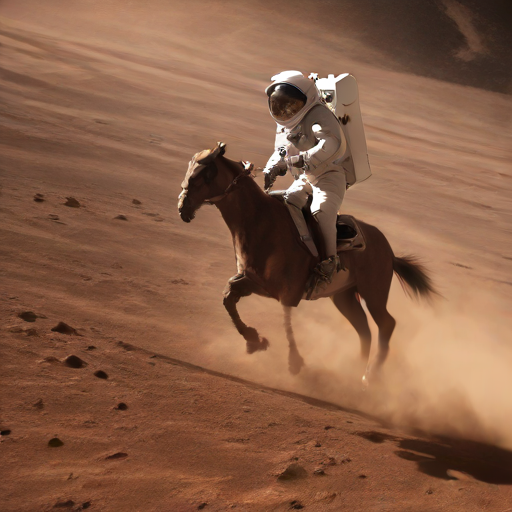

In [38]:
display(target_image)

  0%|          | 0/1 [00:00<?, ?it/s]

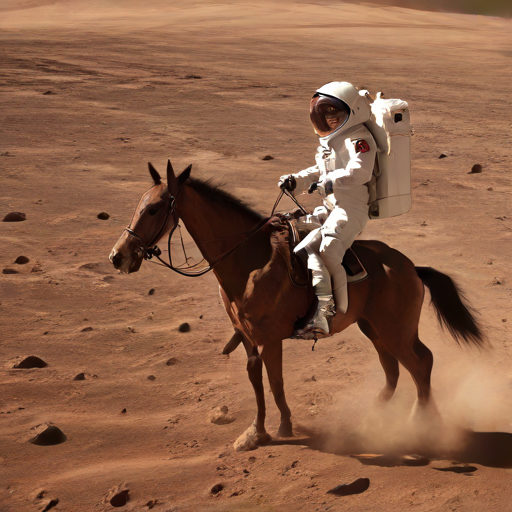

In [43]:
# sample a new image
generator = torch.Generator(device="cuda").manual_seed(1)
image = pipe(
    prompt_embeds=prompt_embeds,
    pooled_prompt_embeds=pooled_prompt_embeds,
    num_images_per_prompt=1,
    generator=generator,
    width=512,
    height=512,
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]
display(image)